<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis - Maestria Integración</strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  27/10/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

# **1. INFORMACION PREVIA**

# **Integración de Variables Geofísicas y Espaciales (S4 – TEC – ROTI – Índices Geomagnéticos/Solares)**

Generar un dataset combinado por tiempo, donde para cada timestamp se tenga:

* El valor de S4 (índice de cintilación) medido cada minuto.

* Los valores de TEC (Contenido Total de Electrones) y ROTI (Tasa de variación del TEC) alineados temporalmente a la resolución del S4.

* Los valores de parámetros geomagnéticos y solares (B, SW, Kp, Dst, Ap, F10.7, AE), interpolados o mantenidos constantes según su resolución original.

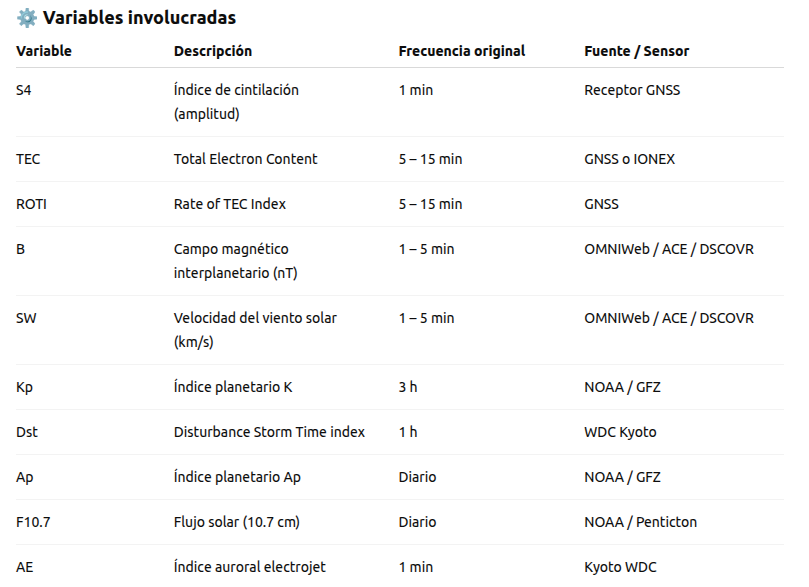

## 🔧 Opciones de Unión Temporal
### Opción 1 – Reescalar TEC y ROTI a 1 minuto

**Propósito:** Mantener la máxima resolución del S4, que captura variabilidad de alta frecuencia.

**Procedimiento:**

1. Tomar la serie temporal de S4 (resolución 1 minuto).

2. Interpolar TEC y ROTI a resolución de 1 minuto usando:

    - Interpolación lineal (method='linear') si se desea suavizar la transición.

    - Forward fill (ffill) si se desea mantener el último valor observado constante.

3. Interpolar o mantener constantes los índices con menor frecuencia (Kp, Dst, etc.) al mismo esquema temporal.

4. Hacer un merge basado en índice de tiempo (datetime).

**Ventajas:**

- Se preserva toda la información de S4.

- Ideal para análisis de alta frecuencia (cintilaciones rápidas).

**Desventajas:**

- Puede introducir interpolaciones artificiales en TEC y ROTI.

- Aumenta el tamaño del dataset.

# **2. PARAMETRO S4-Diciembre 2024**

In [57]:
import os
import pandas as pd


ESTACION      = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
ABREVIATURA   = ["jic","hyo","piu","cuz","pucall","aya","tac","iqui"]

print(f"\n El N° de Estaciones GNSS del IGP en el Peru es: {len(ESTACION)}\n")

N_ESTACION    = 0 # dependiendo del orden podemos seleccionar la ubicacion
PATH          = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
filename      = f"df_max_s4_all_{ABREVIATURA[N_ESTACION]}.csv"

print(f"La estacion seleccionada es:   {ESTACION[N_ESTACION]}\n\n")

file_base_s4  = os.path.join(PATH,filename)
df_max_s4_all =pd.read_csv(file_base_s4)

df_max_s4_all.head()


 El N° de Estaciones GNSS del IGP en el Peru es: 8

La estacion seleccionada es:   JICAMARCA




,ID_Satelite,Tiempo,S4,Azimuth,Elevacion,is_Outlier,Cintilacion
0,9,2023-01-01 00:01:00,0.092,186.0,41.0,False,0
1,9,2023-01-01 00:02:00,0.092,186.0,41.0,False,0
2,9,2023-01-01 00:03:00,0.092,185.0,40.0,False,0
3,9,2023-01-01 00:04:00,0.138,185.0,40.0,False,0
4,6,2023-01-01 00:05:00,0.093,226.0,44.0,False,0


In [59]:
# Ponemos 'timestamp' como índice
df_max_s4_all["Tiempo"] = pd.to_datetime(df_max_s4_all["Tiempo"])
df_max_s4_all = df_max_s4_all.set_index('Tiempo')
df_max_s4_all.head()


,ID_Satelite,S4,Azimuth,Elevacion,is_Outlier,Cintilacion
Tiempo,,,,,,
2023-01-01 00:01:00,9,0.092,186.0,41.0,False,0
2023-01-01 00:02:00,9,0.092,186.0,41.0,False,0
2023-01-01 00:03:00,9,0.092,185.0,40.0,False,0
2023-01-01 00:04:00,9,0.138,185.0,40.0,False,0
2023-01-01 00:05:00,6,0.093,226.0,44.0,False,0


In [61]:
# Filtrar todas las filas del mes de diciembre de 2024
df_diciembre_2024 = df_max_s4_all.loc["2024-12"]
df_diciembre_2024.head()

,ID_Satelite,S4,Azimuth,Elevacion,is_Outlier,Cintilacion
Tiempo,,,,,,
2024-12-01 00:01:00,9,0.111,183.0,40.0,False,0
2024-12-01 00:02:00,96,0.116,217.0,36.0,False,0
2024-12-01 00:03:00,9,0.122,182.0,40.0,False,0
2024-12-01 00:04:00,9,0.132,182.0,40.0,False,0
2024-12-01 00:05:00,6,0.159,222.0,41.0,False,0


In [75]:
# 1 Filtrar los registros con Cintilación = 1
df_cintilacion = df_diciembre_2024[df_diciembre_2024["Cintilacion"] == 1]
#  Ver los días (fechas únicas) donde hubo Cintilación = 1
dias_cintilacion = df_cintilacion.index.normalize().unique()
print("Días con Cintilación detectada:\n", dias_cintilacion)
# 3 (Opcional) Contar cuántos días hubo Cintilación
n_dias_cintilacion = len(dias_cintilacion)
print(f"Número de días con Cintilación: {n_dias_cintilacion}")
# 4 Muestras por cintilacion en un dia
cintilacion_por_dia = df_cintilacion.groupby(df_cintilacion.index.date).size()
print("Cintilacion por dia:",cintilacion_por_dia)

Días con Cintilación detectada:
 DatetimeIndex(['2024-12-02'], dtype='datetime64[ns]', name='Tiempo', freq=None)
Número de días con Cintilación: 1
Cintilacion por dia: 2024-12-02    1
dtype: int64


In [137]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

def graficar_cintilacion_dia(df_dia, nombre_estacion="Estación", fecha=None, guardar=False, ruta_salida=None):
    """
    Grafica los eventos de cintilación para una estación y día determinados.

    Parámetros:
    ------------
    df_dia : pd.DataFrame
        DataFrame con las columnas ["S4", "Cintilacion"] y un índice de tipo datetime.
    nombre_estacion : str
        Nombre de la estación GNSS o del sitio de medición (opcional).
    fecha : datetime o str
        Fecha del día analizado (opcional, para mostrar en el título).
    guardar : bool
        Si True, guarda el gráfico en una imagen PNG de alta resolución.
    ruta_salida : str
        Ruta donde se guardará el archivo (si guardar=True). Ej: "resultados/graficos/"

    Retorna:
    --------
    None (muestra o guarda el gráfico)
    """

    # Validación básica
    if "S4" not in df_dia.columns or "Cintilacion" not in df_dia.columns:
        raise ValueError("El DataFrame debe contener las columnas 'S4' y 'Cintilacion'.")

    # Configuración de estilo
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11
    })

    # Filtrar eventos
    df_cintilacion = df_dia[df_dia["Cintilacion"] == 1]
    total_eventos = len(df_cintilacion)

    # Crear figura
    fig, ax = plt.subplots(figsize=(14, 6))

    # Señal S4 completa
    ax.plot(df_dia.index, df_dia["S4"], 
            color="steelblue", linewidth=1.5, label="S4 (índice total)")

    # Eventos de cintilación
    ax.scatter(df_cintilacion.index, df_cintilacion["S4"],
               color="crimson", s=45, edgecolor="white", linewidth=0.7,
               zorder=3, label="Cintilación detectada (S4 > umbral)")

    # Formato del eje X (horas)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.xticks(rotation=45)

    # Título dinámico
    if fecha is None:
        fecha = df_dia.index[0].strftime("%d %B %Y")
    else:
        try:
            fecha = pd.to_datetime(fecha).strftime("%d %B %Y")
        except:
            pass

    ax.set_title(f"Eventos de Cintilación – {nombre_estacion} – {fecha}",
                 fontsize=16, fontweight="bold", color="navy", pad=15)
    ax.set_xlabel("Hora local (UTC-5)")
    ax.set_ylabel("Índice S4", fontweight="bold")

    # Cuadro informativo
    ax.text(0.15, 0.92, f"Total eventos: {total_eventos}",
            transform=ax.transAxes, fontsize=11, color="darkred",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="lightgray"))

    # Decoración
    ax.legend(frameon=True, fancybox=True, shadow=False,
              loc="upper right", framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.4)
    sns.despine(left=False, bottom=False)

    plt.tight_layout()

    # Guardar si se solicita
    if guardar:
        if ruta_salida is None:
            ruta_salida = "./"
        nombre_archivo = f"{ruta_salida}/cintilacion_{nombre_estacion}_{fecha.replace(' ', '_')}.png"
        plt.savefig(nombre_archivo, dpi=300, bbox_inches="tight")
        print(f"✅ Gráfico guardado en: {nombre_archivo}")
    else:
        plt.show()

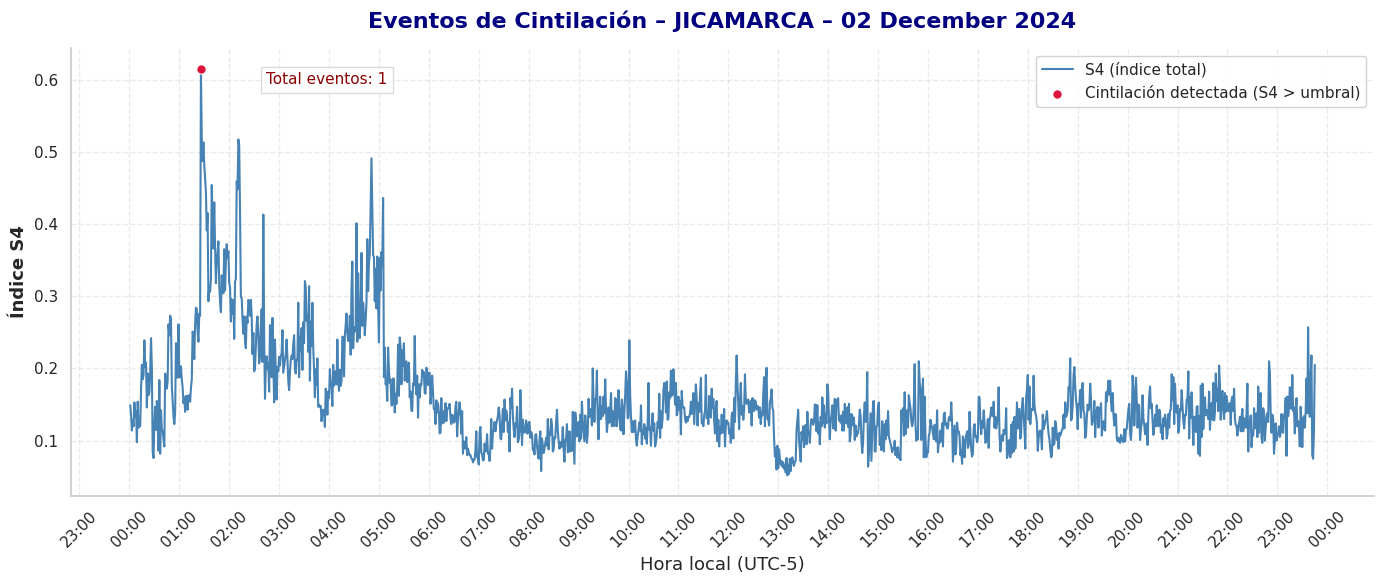

In [139]:
# Ejemplo de uso
dia = cintilacion_por_dia.index[0]
nombre_estacion = "JICAMARCA"
df_dia = df_max_s4_all.loc[str(dia)]  # Filtras el día
graficar_cintilacion_dia(df_dia, nombre_estacion, fecha=dia)


# **PRUEBA AUTOMATIZADA**

In [144]:
import os
import pandas as pd

def analizar_estacion_mes(
        N_ESTACION:int,
        MES:str,
        ESTACIONES:list,
        ABREVIATURAS:list,
        PATH_BASE:str,
        guardar_graficos=False,
        ruta_salida="graficos"):
    """
    Analiza la actividad de cintilación para una estación y mes específico.
    Carga, filtra, detecta días con cintilaciones y genera gráficos diarios.

    Parámetros:
    ------------
    N_ESTACION : int
        Índice de la estación (según las listas ESTACIONES y ABREVIATURAS)
    MES : str
        Mes y año en formato 'YYYY-MM' (por ejemplo: '2024-12')
    ESTACIONES : list
        Lista de nombres completos de las estaciones
    ABREVIATURAS : list
        Lista de abreviaturas correspondientes a las estaciones
    PATH_BASE : str
        Ruta base donde están los CSV por estación
    guardar_graficos : bool
        Si True, guarda las figuras generadas
    ruta_salida : str
        Carpeta de salida para los gráficos (si guardar_graficos=True)

    Retorna:
    --------
    df_diciembre : pd.DataFrame
        DataFrame filtrado del mes
    dias_cintilacion : list
        Lista de días (datetime.date) donde se detectó cintilación
    """

    estacion = ESTACIONES[N_ESTACION]
    abrev = ABREVIATURAS[N_ESTACION]

    print(f"\n📡 Estación seleccionada: {estacion.upper()}")
    print(f"📅 Mes seleccionado: {MES}\n")

    # --- 1. Cargar los datos ---
    filename = f"df_max_s4_all_{abrev}.csv"
    filepath = os.path.join(PATH_BASE, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"No se encontró el archivo: {filepath}")

    df = pd.read_csv(filepath)
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])
    df = df.set_index("Tiempo")

    # --- 2. Filtrar por mes ---
    df_mes = df.loc[MES]

    # --- 3. Filtrar registros con Cintilación = 1 ---
    df_cint = df_mes[df_mes["Cintilacion"] == 1]

    # --- 4. Identificar días únicos con cintilaciones ---
    dias_cintilacion = df_cint.index.normalize().unique()
    n_dias = len(dias_cintilacion)

    print(f"✅ Días con Cintilación detectada: {n_dias}")
    for d in dias_cintilacion:
        print(f"   • {d.date()}")

    # --- 5. Conteo por día ---
    cintilacion_por_dia = df_cint.groupby(df_cint.index.date).size()
    print("\n📊 Muestras con Cintilación por día:\n", cintilacion_por_dia)

    # --- 6. Generar gráficos para cada día ---
    if guardar_graficos:
        os.makedirs(ruta_salida, exist_ok=True)

    for dia in dias_cintilacion:
        df_dia = df_mes.loc[str(dia.date())]
        graficar_cintilacion_dia(
            df_dia, 
            nombre_estacion=estacion, 
            fecha=dia, 
            guardar=guardar_graficos, 
            ruta_salida=ruta_salida
        )

    print(f"\n🎨 Gráficos generados exitosamente para {n_dias} días de {estacion}.\n")

    return df_mes, dias_cintilacion


📡 Estación seleccionada: JICAMARCA
📅 Mes seleccionado: 2024-12

✅ Días con Cintilación detectada: 1
   • 2024-12-02

📊 Muestras con Cintilación por día:
 2024-12-02    1
dtype: int64
✅ Gráfico guardado en: resultados/plots/cintilacion_JICAMARCA_02_December_2024.png

🎨 Gráficos generados exitosamente para 1 días de JICAMARCA.



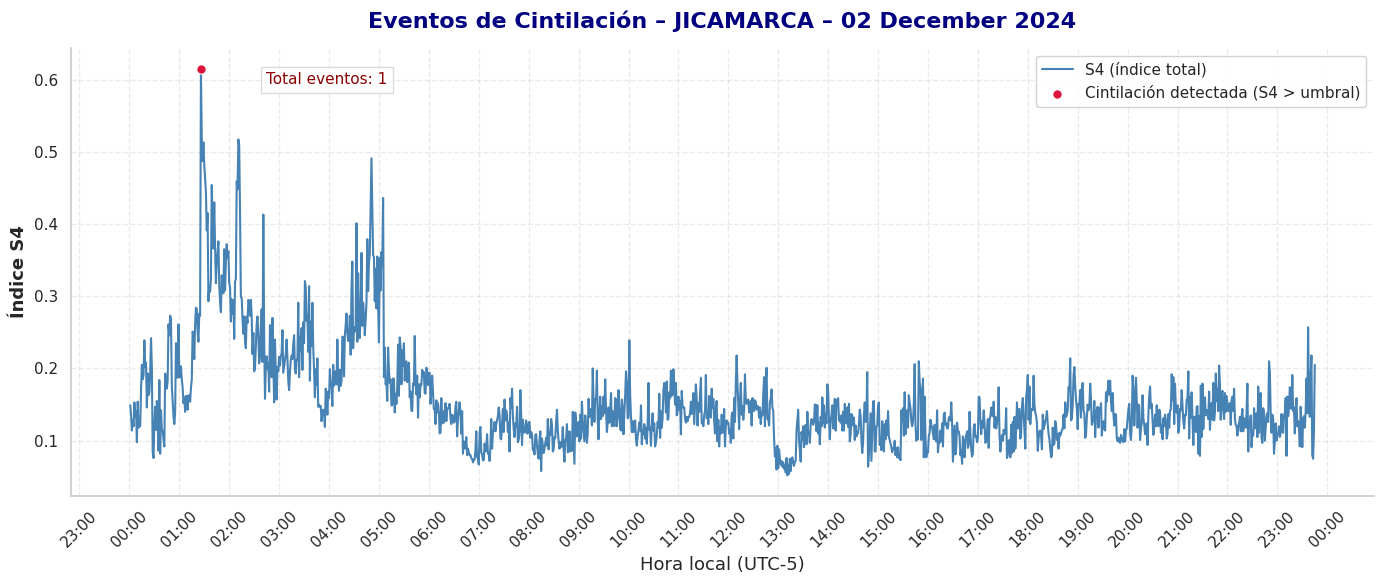

In [152]:
# Listas de estaciones
ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
ABREVIATURA = ["jic","hyo","piu","cuz","pucall","aya","tac","iqui"]

# Ruta base de tus CSV
PATH = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"

# Ejemplo: analizar diciembre 2024 para HUANCAYO
N_ESTACION = 0  # JICAMARCA
MES = "2024-12"

df_mes, dias_cint = analizar_estacion_mes(
    N_ESTACION,
    MES,
    ESTACION,
    ABREVIATURA,
    PATH_BASE=PATH,
    guardar_graficos=True,
    ruta_salida="resultados/plots"
)


📡 Estación seleccionada: HUANCAYO
📅 Mes seleccionado: 2024-12

✅ Días con Cintilación detectada: 3
   • 2024-12-02
   • 2024-12-03
   • 2024-12-05

📊 Muestras con Cintilación por día:
 2024-12-02    1
2024-12-03    2
2024-12-05    1
dtype: int64
✅ Gráfico guardado en: resultados/plots/cintilacion_HUANCAYO_02_December_2024.png
✅ Gráfico guardado en: resultados/plots/cintilacion_HUANCAYO_03_December_2024.png
✅ Gráfico guardado en: resultados/plots/cintilacion_HUANCAYO_05_December_2024.png

🎨 Gráficos generados exitosamente para 3 días de HUANCAYO.



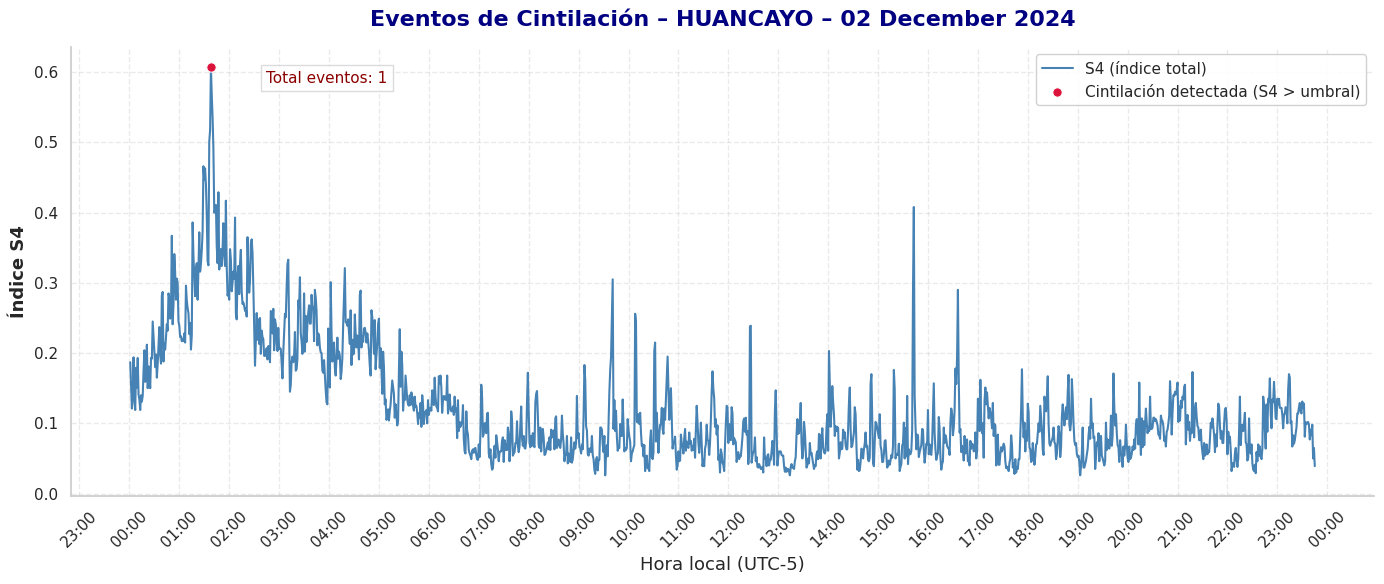

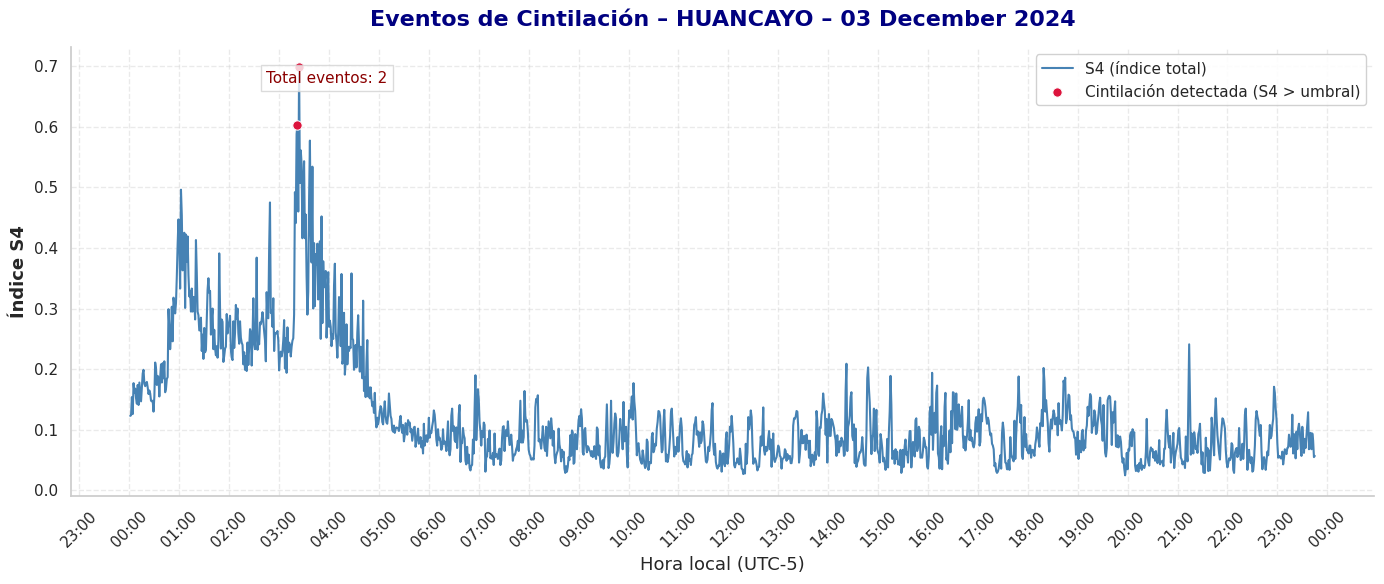

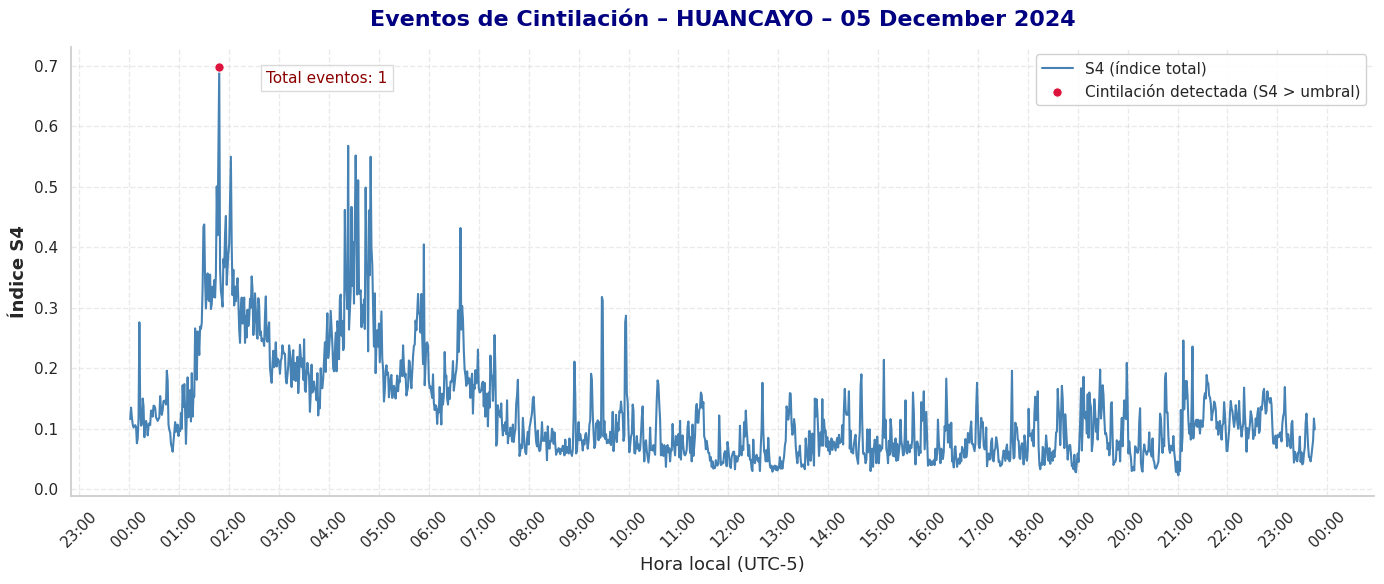

In [146]:
# Listas de estaciones
ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
ABREVIATURA = ["jic","hyo","piu","cuz","pucall","aya","tac","iqui"]

# Ruta base de tus CSV
PATH = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"

# Ejemplo: analizar diciembre 2024 para HUANCAYO
N_ESTACION = 1  # HUANCAYO
MES = "2024-12"

df_mes, dias_cint = analizar_estacion_mes(
    N_ESTACION,
    MES,
    ESTACION,
    ABREVIATURA,
    PATH_BASE=PATH,
    guardar_graficos=True,
    ruta_salida="resultados/plots"
)


📡 Estación seleccionada: PIURA
📅 Mes seleccionado: 2024-12

✅ Días con Cintilación detectada: 14
   • 2024-12-02
   • 2024-12-03
   • 2024-12-04
   • 2024-12-05
   • 2024-12-06
   • 2024-12-08
   • 2024-12-09
   • 2024-12-12
   • 2024-12-13
   • 2024-12-14
   • 2024-12-15
   • 2024-12-23
   • 2024-12-25
   • 2024-12-30

📊 Muestras con Cintilación por día:
 2024-12-02    26
2024-12-03     7
2024-12-04    14
2024-12-05    18
2024-12-06     9
2024-12-08     8
2024-12-09    10
2024-12-12     1
2024-12-13     7
2024-12-14     4
2024-12-15     3
2024-12-23     1
2024-12-25     1
2024-12-30     1
dtype: int64
✅ Gráfico guardado en: resultados/plots/cintilacion_PIURA_02_December_2024.png
✅ Gráfico guardado en: resultados/plots/cintilacion_PIURA_03_December_2024.png
✅ Gráfico guardado en: resultados/plots/cintilacion_PIURA_04_December_2024.png
✅ Gráfico guardado en: resultados/plots/cintilacion_PIURA_05_December_2024.png
✅ Gráfico guardado en: resultados/plots/cintilacion_PIURA_06_December_202

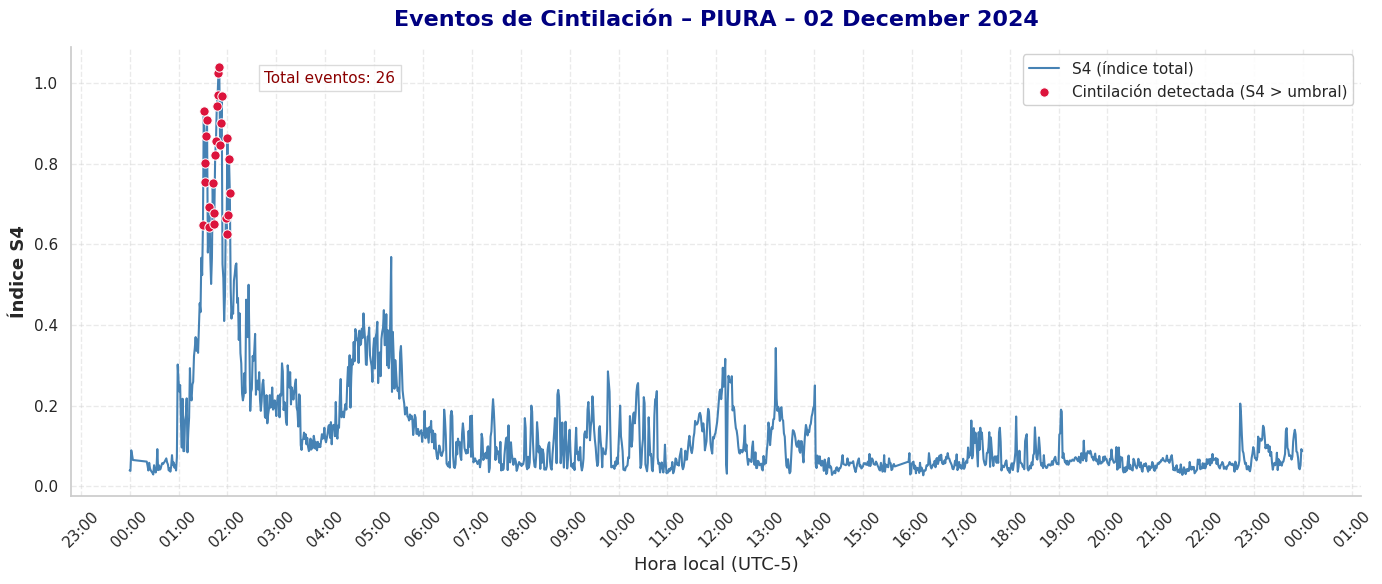

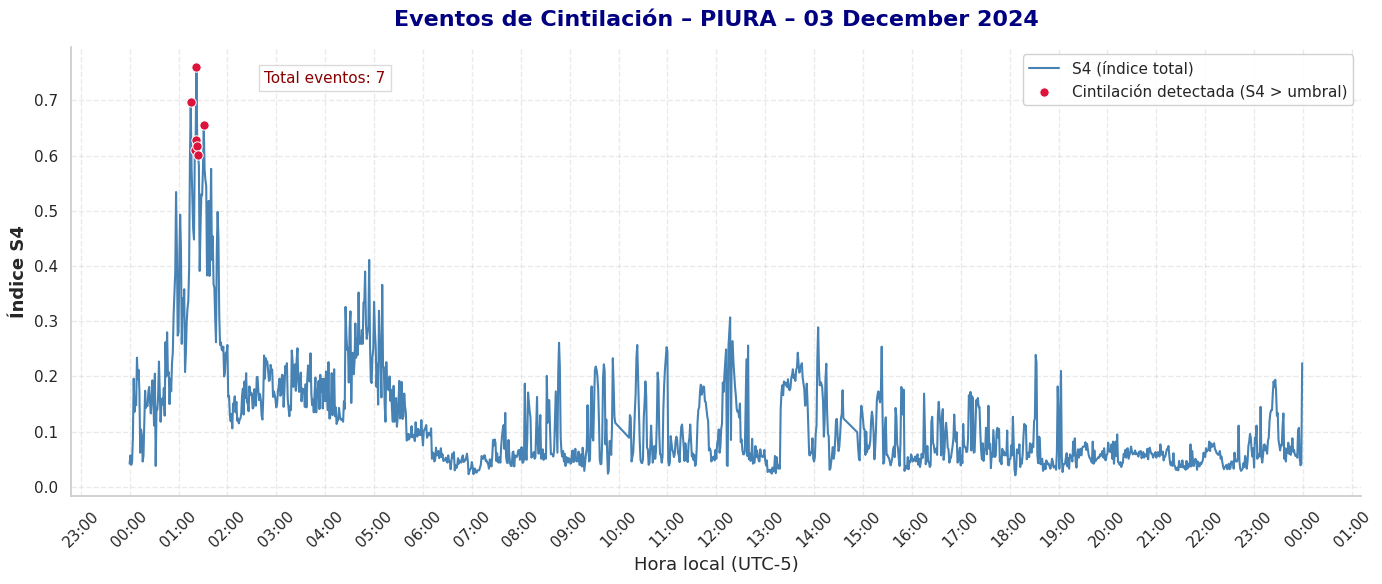

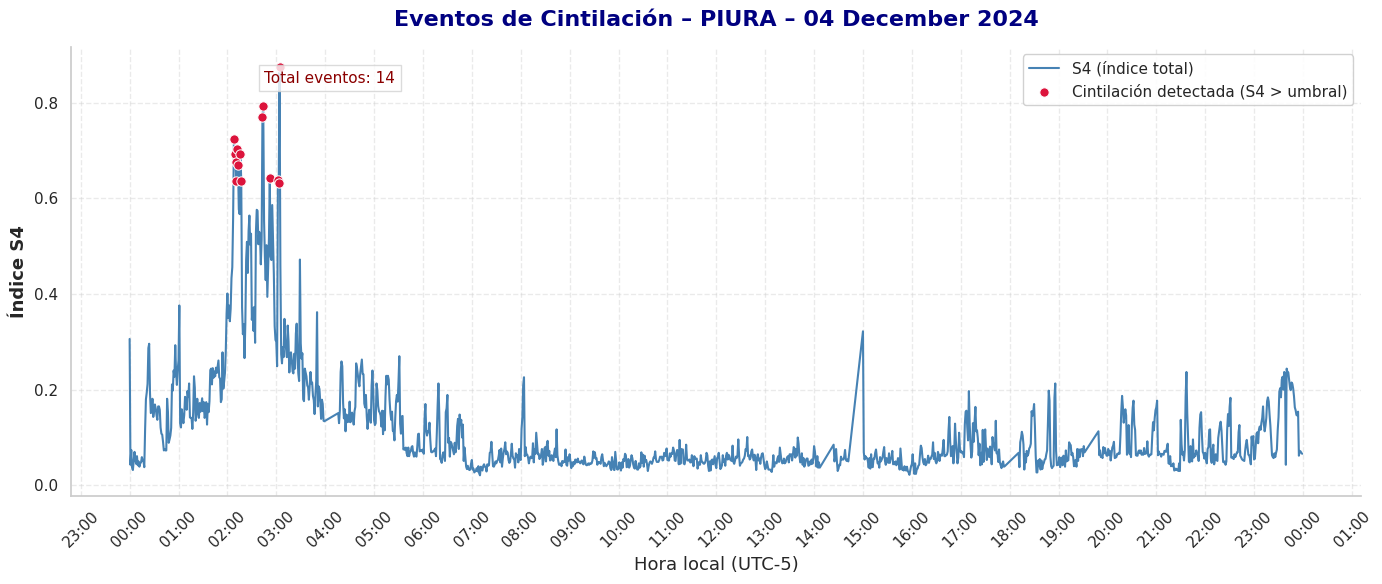

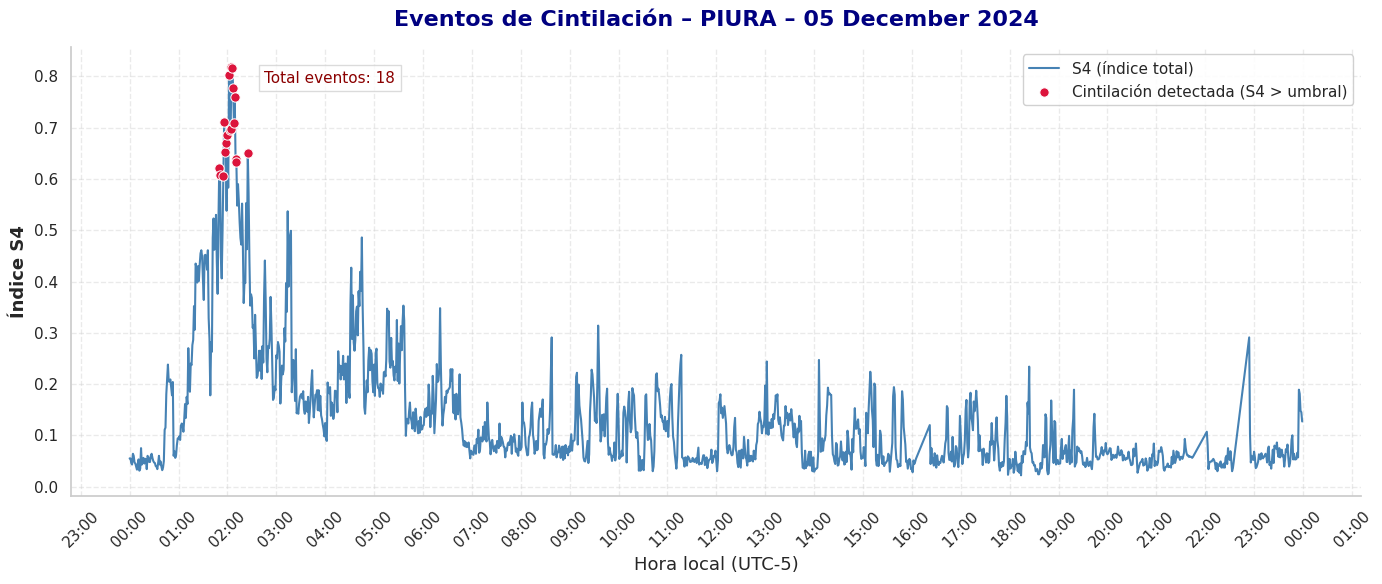

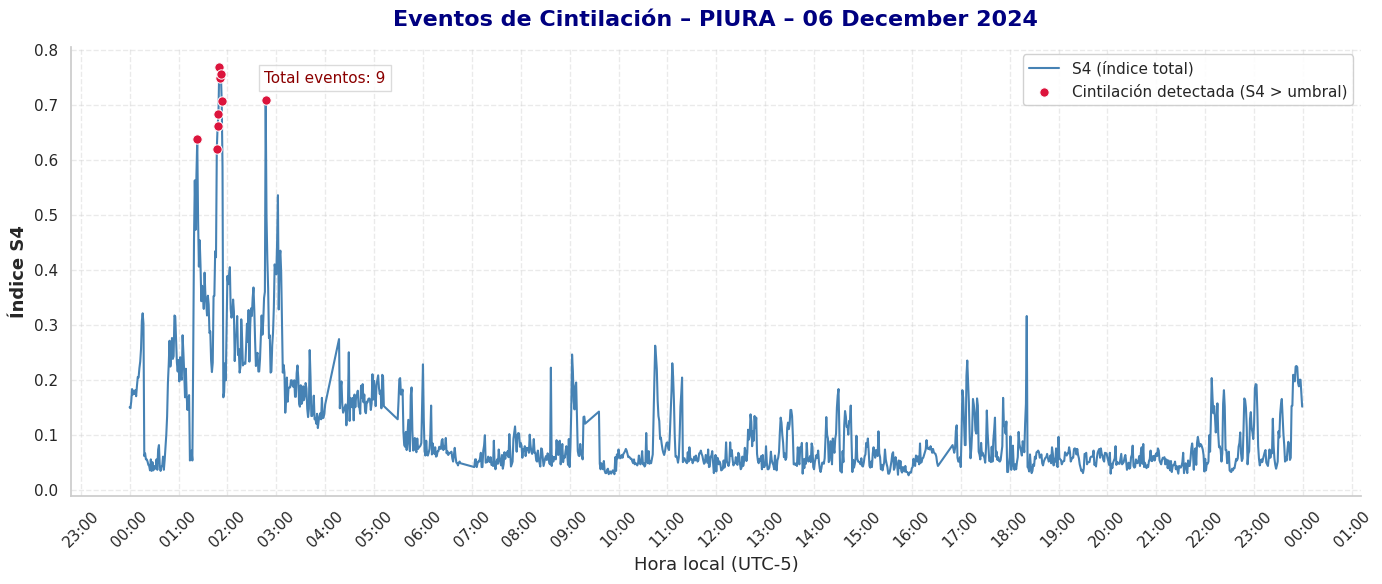

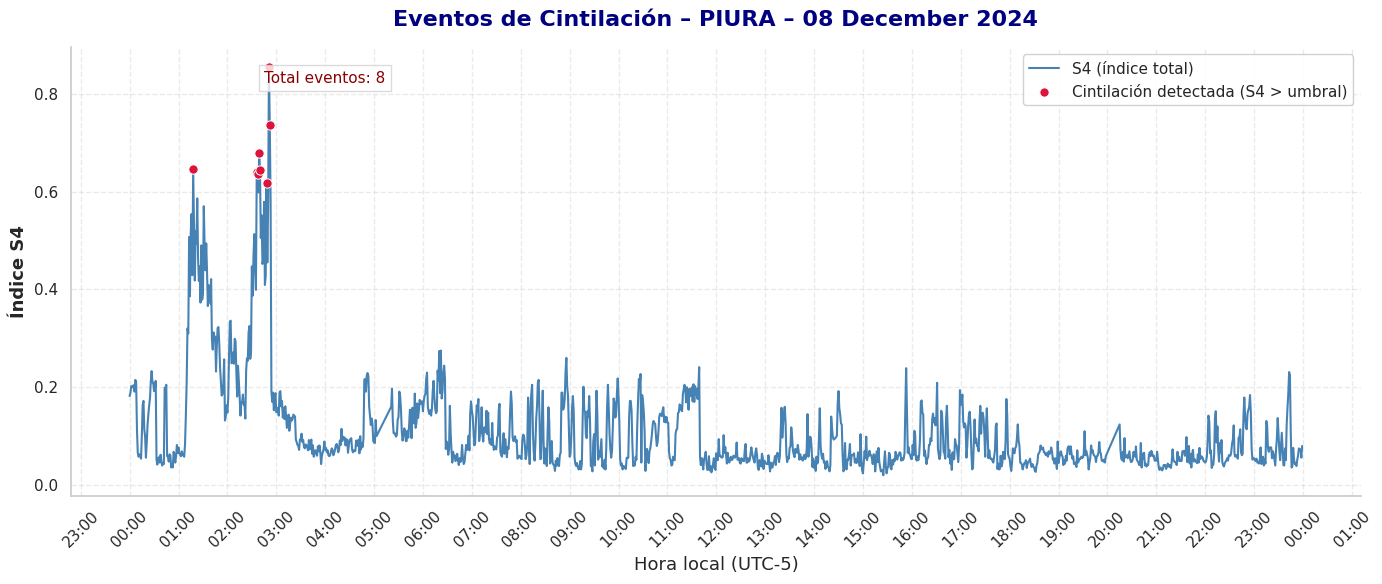

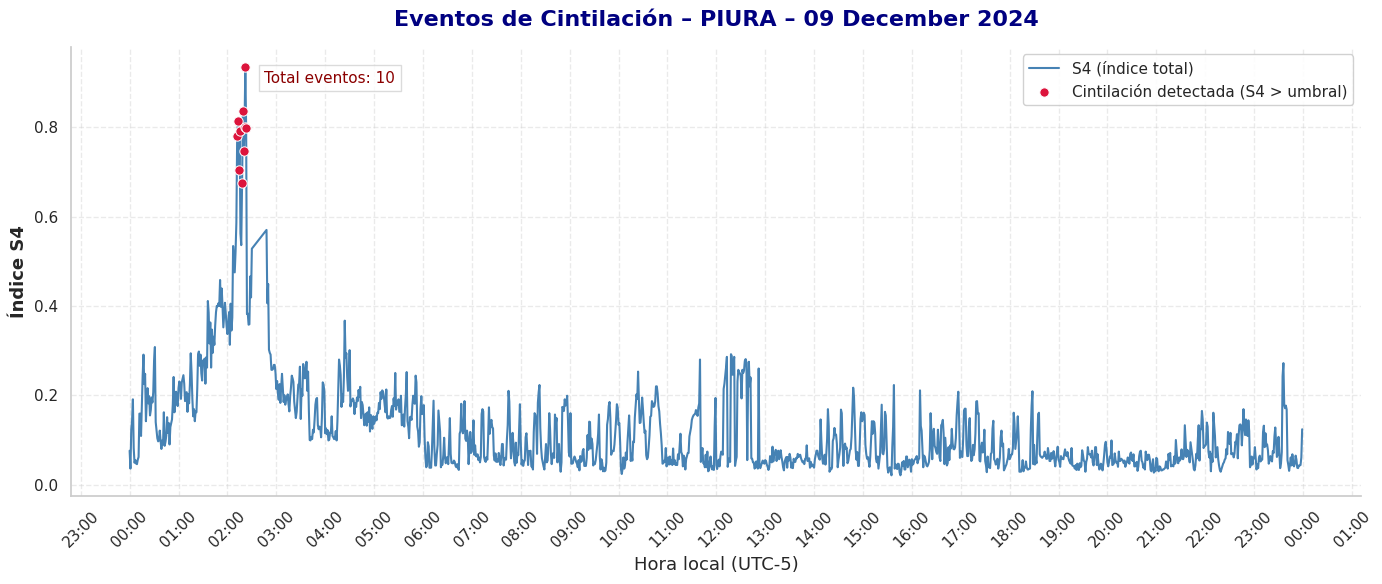

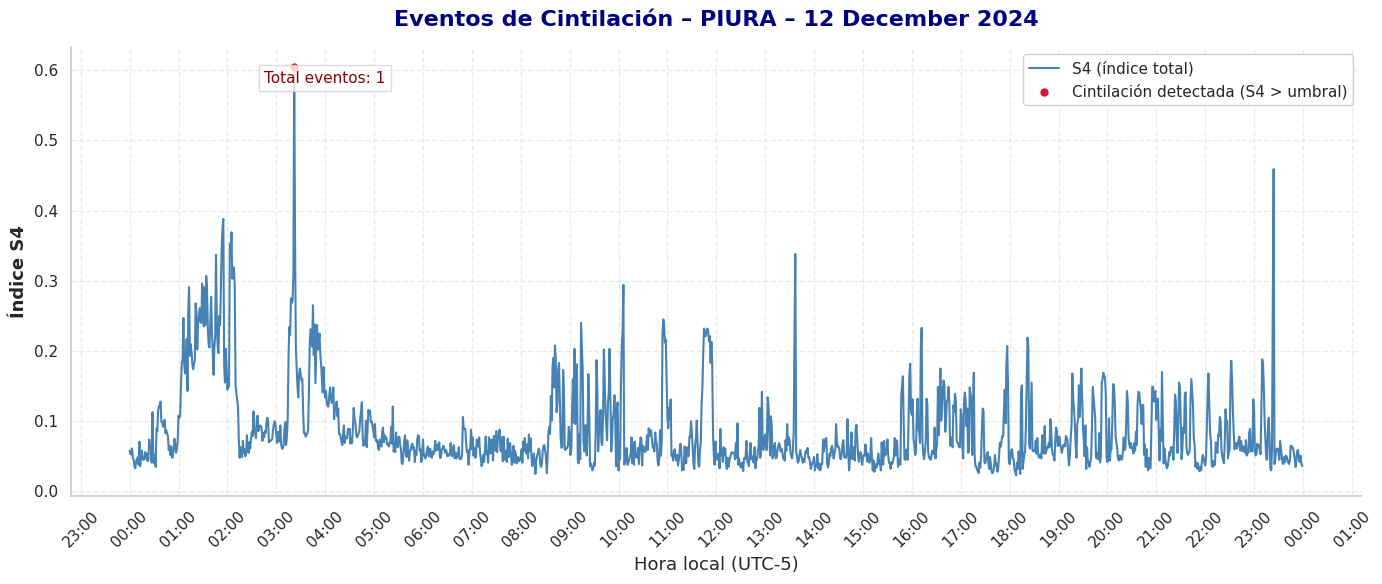

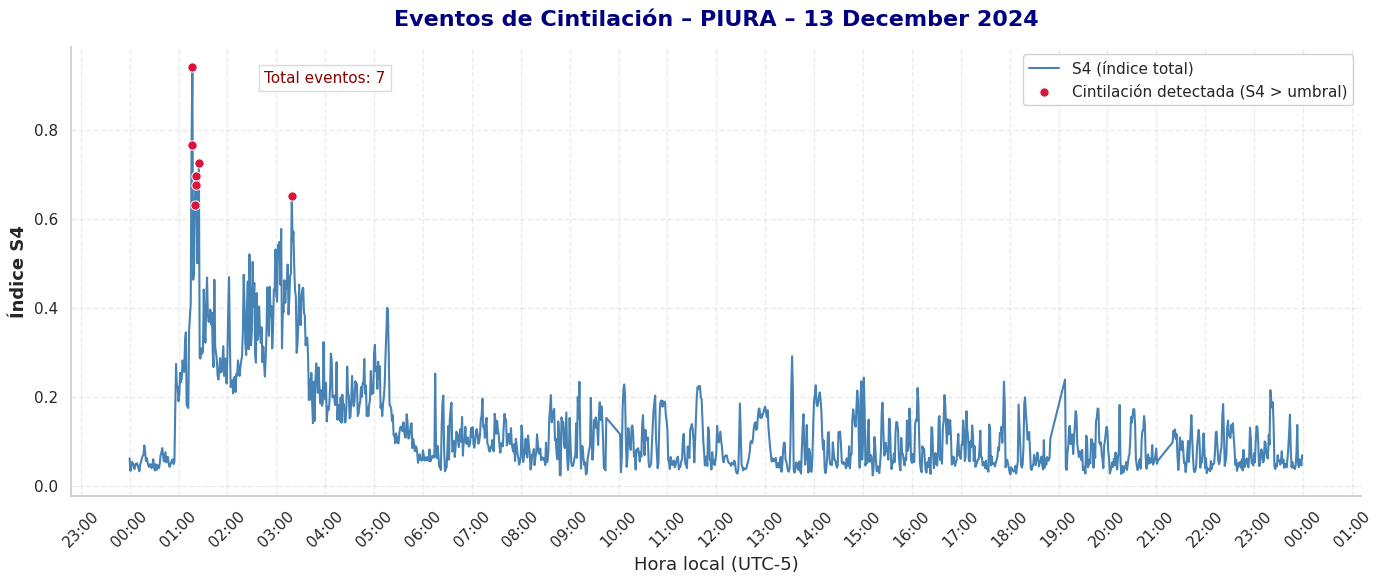

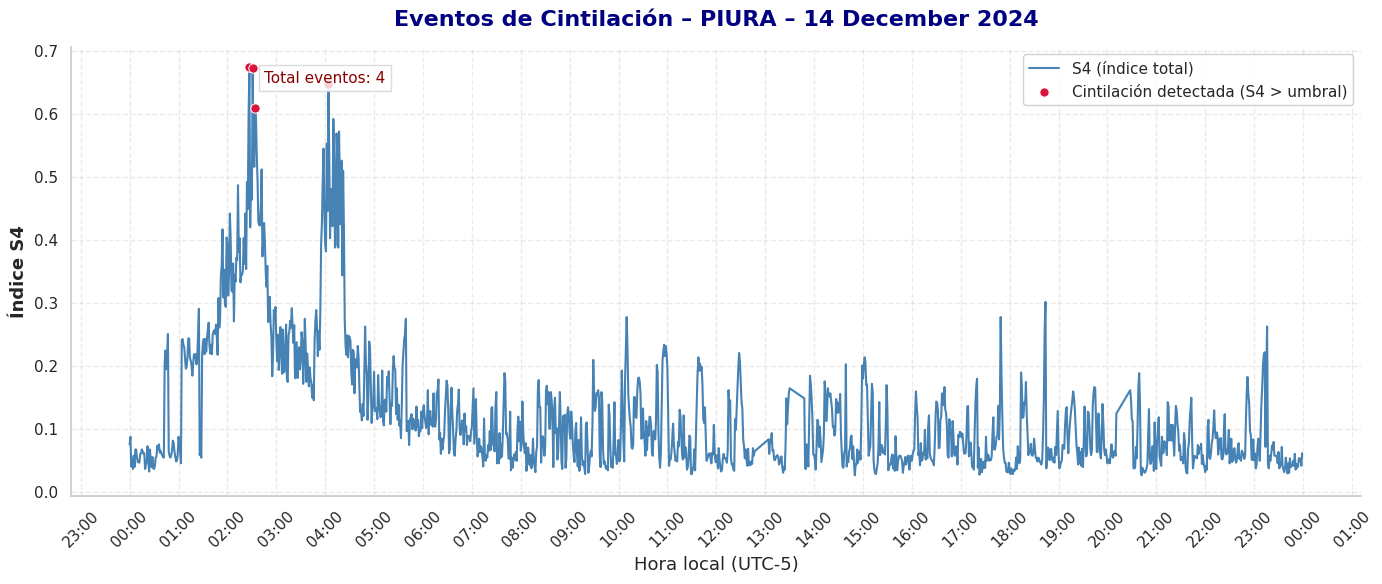

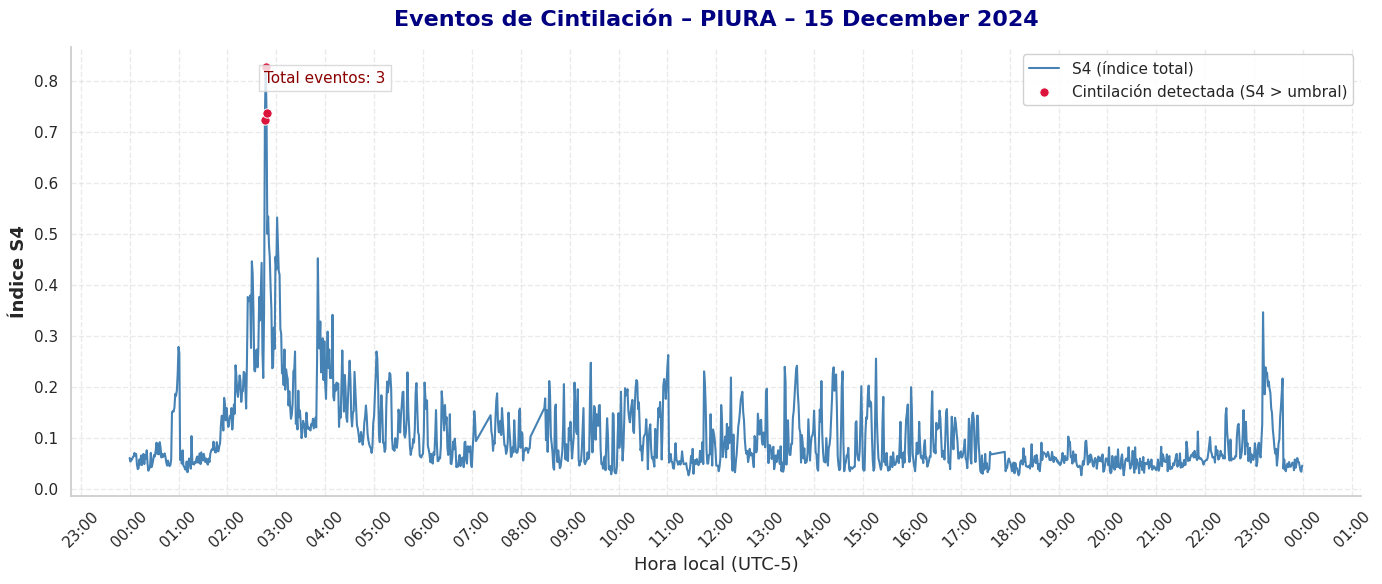

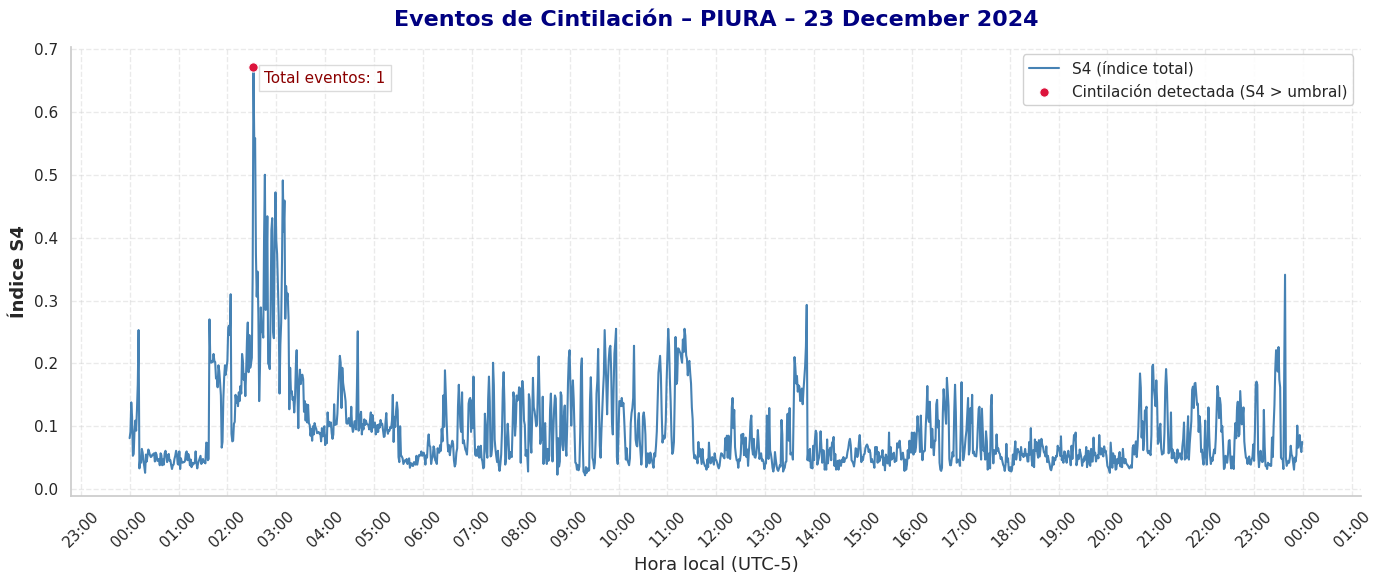

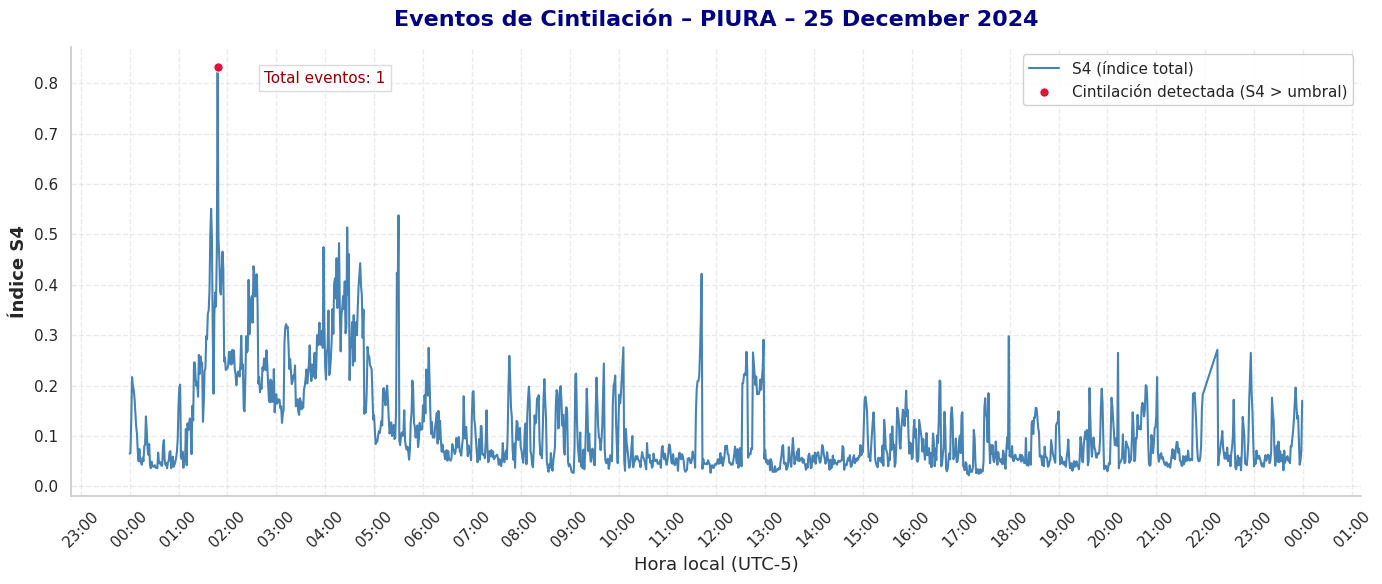

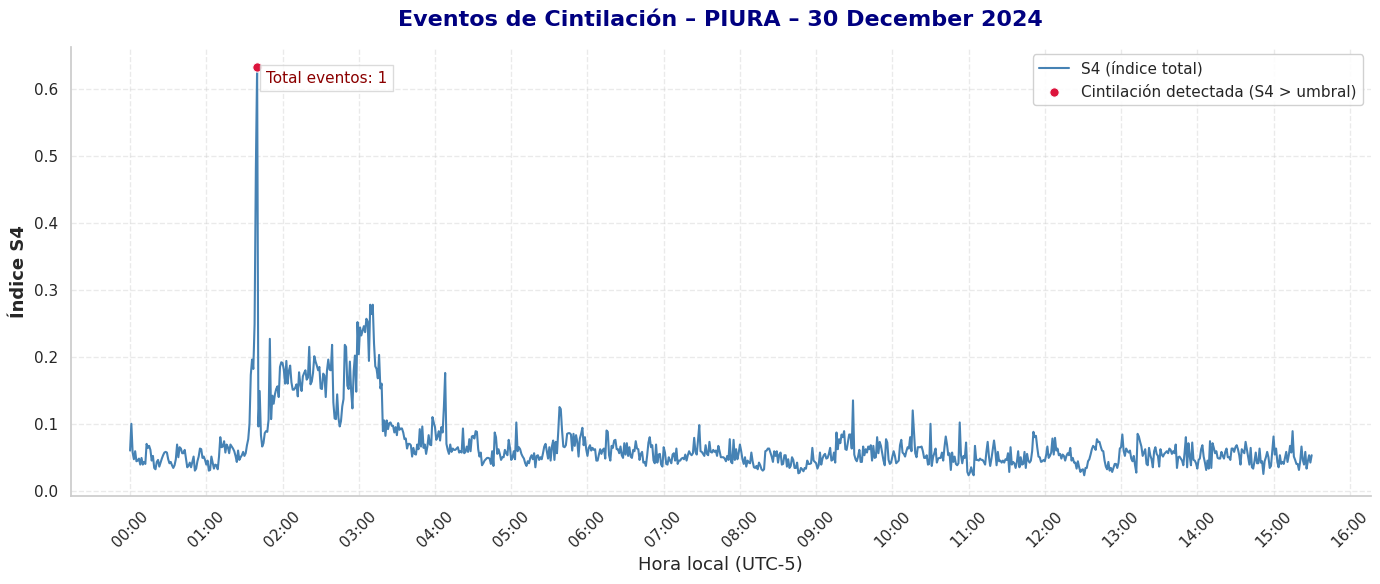

In [148]:
# Listas de estaciones
ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
ABREVIATURA = ["jic","hyo","piu","cuz","pucall","aya","tac","iqui"]

# Ruta base de tus CSV
PATH = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
# Ejemplo: analizar diciembre 2024 para PIURA
N_ESTACION = 2  # HUANCAYO
MES = "2024-12"

df_mes, dias_cint = analizar_estacion_mes(
    N_ESTACION,
    MES,
    ESTACION,
    ABREVIATURA,
    PATH_BASE=PATH,
    guardar_graficos=True,
    ruta_salida="resultados/plots"
)